# NeuroGolf Base Visualization

タスク番号を指定して、`train` / `test` / `arc-gen` の input/output グリッドを可視化するベースNotebook。

In [1]:
from pathlib import Path
import json
import os

def find_project_root(start=Path.cwd()):
    for path in [start, *start.parents]:
        if (path / "neurogolf-2026").is_dir():
            return path
    raise FileNotFoundError("project root not found")


ROOT = find_project_root()
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".matplotlib-cache"))

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

## タスク番号を指定

In [2]:
# ここだけ変更する
TASK_NUM = 1

In [3]:
def find_data_dir():
    candidates = [
        Path("/kaggle/input/competitions/neurogolf-2026"),
        Path("/kaggle/input/neurogolf-2026"),
        ROOT / "neurogolf-2026",
        Path.cwd() / "neurogolf-2026",
        Path("neurogolf-2026"),
    ]
    for path in candidates:
        if path.exists() and path.is_dir():
            return path
    raise FileNotFoundError("neurogolf-2026 data directory was not found")


DATA_DIR = find_data_dir()
TASK_PATH = DATA_DIR / f"task{TASK_NUM:03d}.json"

print(f"DATA_DIR: {DATA_DIR}")
print(f"TASK_PATH: {TASK_PATH}")

DATA_DIR: /Users/kaiikeda/Programming/Kaggle/Neuro Golf/neurogolf-2026
TASK_PATH: /Users/kaiikeda/Programming/Kaggle/Neuro Golf/neurogolf-2026/task001.json


In [4]:
def load_task(task_num, data_dir=DATA_DIR):
    path = data_dir / f"task{task_num:03d}.json"
    with path.open("r") as f:
        return json.load(f)


task = load_task(TASK_NUM)

for split in ["train", "test", "arc-gen"]:
    print(f"{split}: {len(task.get(split, []))} pairs")

train: 5 pairs
test: 1 pairs
arc-gen: 262 pairs


## 可視化関数

In [5]:
ARC_COLORS = [
    "#000000",  # 0 black
    "#1e93ff",  # 1 blue
    "#fa3d31",  # 2 red
    "#4ecc30",  # 3 green
    "#ffdd00",  # 4 yellow
    "#999999",  # 5 gray
    "#e53ba3",  # 6 magenta
    "#ff851c",  # 7 orange
    "#88d8f1",  # 8 cyan
    "#931131",  # 9 maroon
]

cmap = ListedColormap(ARC_COLORS)
norm = BoundaryNorm(np.arange(-0.5, 10.5, 1), cmap.N)


def grid_shape(grid):
    arr = np.asarray(grid)
    return f"{arr.shape[0]}x{arr.shape[1]}"


def plot_grid(ax, grid, title=""):
    arr = np.asarray(grid)
    ax.imshow(arr, cmap=cmap, norm=norm, interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.set_xticks(np.arange(-0.5, arr.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, arr.shape[0], 1), minor=True)
    ax.grid(which="minor", color="#d0d0d0", linewidth=0.6)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
    for spine in ax.spines.values():
        spine.set_visible(False)


def visualize_pairs(pairs, split_name, max_pairs=None):
    shown = pairs if max_pairs is None else pairs[:max_pairs]
    if not shown:
        print(f"{split_name}: no pairs")
        return

    fig, axes = plt.subplots(
        len(shown),
        2,
        figsize=(6, max(2.2, len(shown) * 2.2)),
        squeeze=False,
        constrained_layout=True,
    )
    fig.suptitle(f"task{TASK_NUM:03d} - {split_name} ({len(shown)}/{len(pairs)} pairs)", fontsize=14)

    for i, pair in enumerate(shown):
        inp = pair["input"]
        out = pair["output"]
        plot_grid(axes[i, 0], inp, f"input {i} ({grid_shape(inp)})")
        plot_grid(axes[i, 1], out, f"output {i} ({grid_shape(out)})")

    plt.show()

## train / test / arc-gen を表示

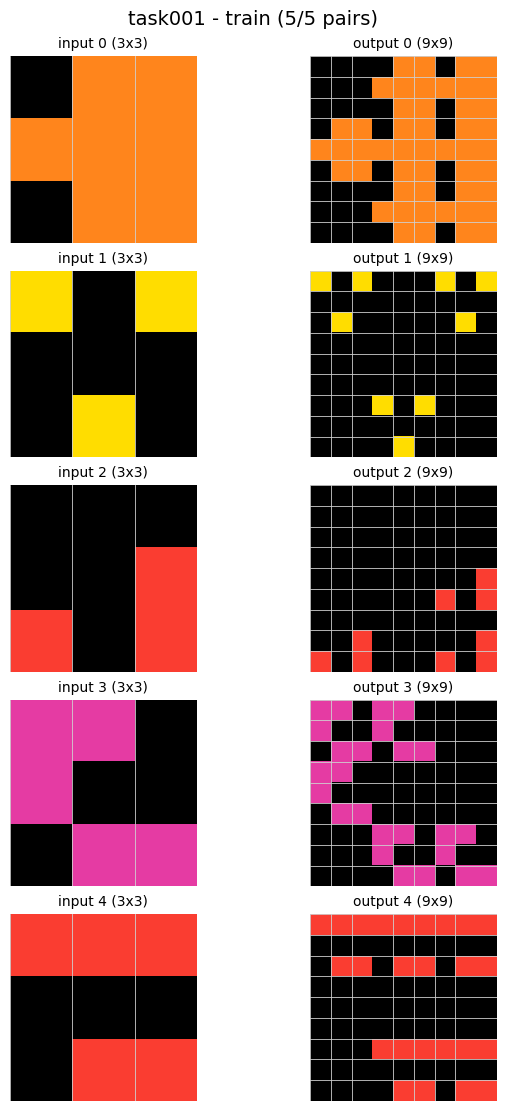

In [6]:
visualize_pairs(task["train"], "train")

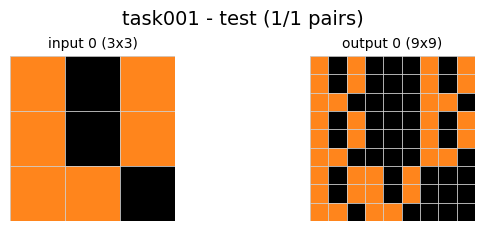

In [7]:
visualize_pairs(task["test"], "test")

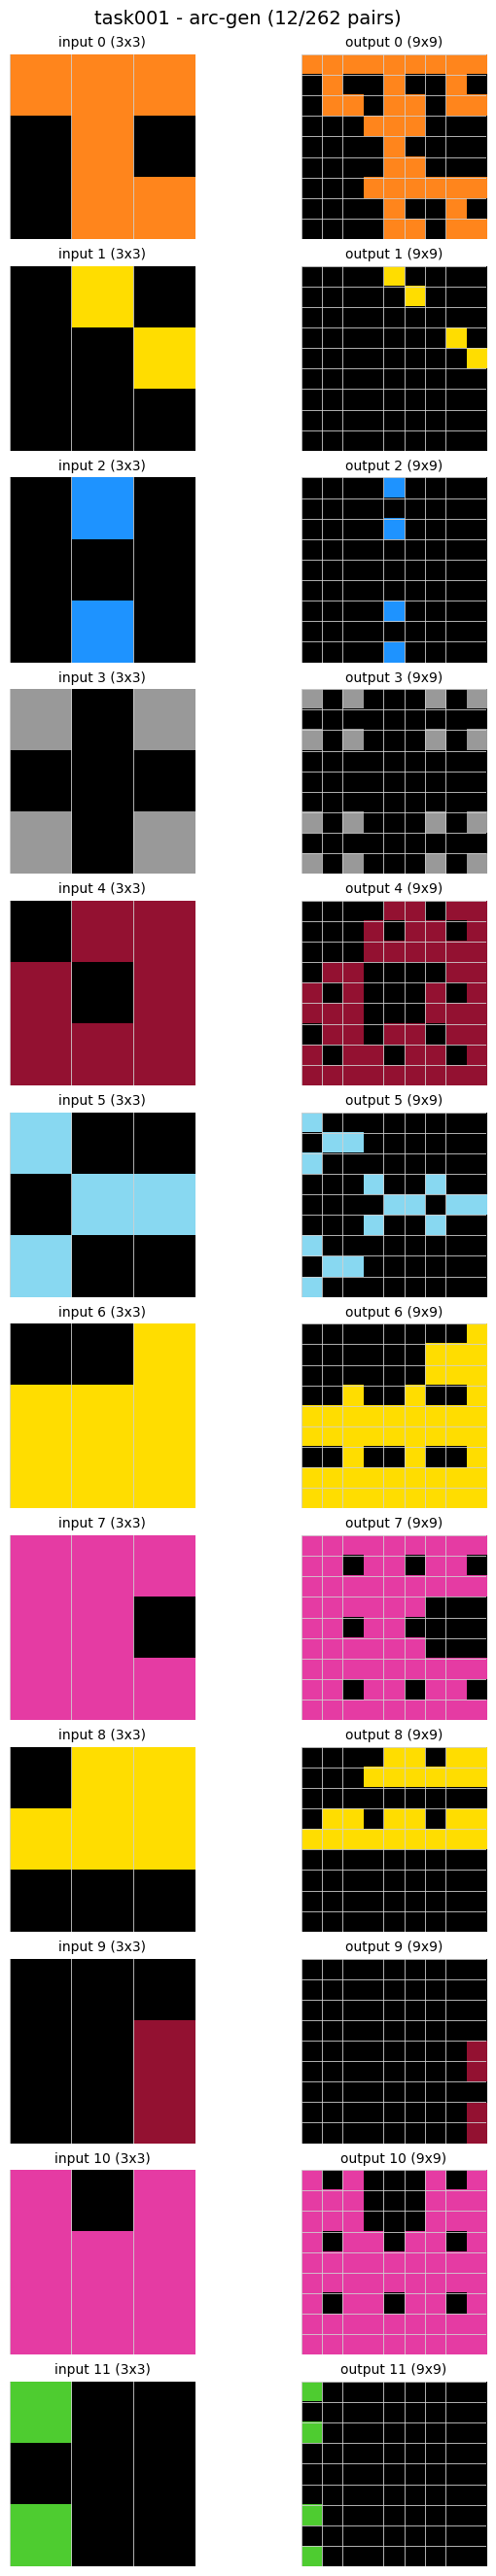

In [8]:
# arc-gen は多い場合があるため、まずは先頭だけ表示
visualize_pairs(task["arc-gen"], "arc-gen", max_pairs=12)

## グリッド値とサイズの確認

In [9]:
def summarize_split(pairs, split_name):
    rows = []
    for i, pair in enumerate(pairs):
        inp = np.asarray(pair["input"])
        out = np.asarray(pair["output"])
        rows.append({
            "split": split_name,
            "idx": i,
            "input_shape": inp.shape,
            "output_shape": out.shape,
            "input_colors": sorted(np.unique(inp).tolist()),
            "output_colors": sorted(np.unique(out).tolist()),
        })
    return rows


summary = []
for split in ["train", "test", "arc-gen"]:
    summary.extend(summarize_split(task[split], split))

summary[:20]

[{'split': 'train',
  'idx': 0,
  'input_shape': (3, 3),
  'output_shape': (9, 9),
  'input_colors': [0, 7],
  'output_colors': [0, 7]},
 {'split': 'train',
  'idx': 1,
  'input_shape': (3, 3),
  'output_shape': (9, 9),
  'input_colors': [0, 4],
  'output_colors': [0, 4]},
 {'split': 'train',
  'idx': 2,
  'input_shape': (3, 3),
  'output_shape': (9, 9),
  'input_colors': [0, 2],
  'output_colors': [0, 2]},
 {'split': 'train',
  'idx': 3,
  'input_shape': (3, 3),
  'output_shape': (9, 9),
  'input_colors': [0, 6],
  'output_colors': [0, 6]},
 {'split': 'train',
  'idx': 4,
  'input_shape': (3, 3),
  'output_shape': (9, 9),
  'input_colors': [0, 2],
  'output_colors': [0, 2]},
 {'split': 'test',
  'idx': 0,
  'input_shape': (3, 3),
  'output_shape': (9, 9),
  'input_colors': [0, 7],
  'output_colors': [0, 7]},
 {'split': 'arc-gen',
  'idx': 0,
  'input_shape': (3, 3),
  'output_shape': (9, 9),
  'input_colors': [0, 7],
  'output_colors': [0, 7]},
 {'split': 'arc-gen',
  'idx': 1,
  'inp